# Project Data Exploration Questions
Group name: Team6

Created by Brian Luong (016187743), Andrew Chen (018035679), Joshua Layokun (016336281)

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
# Visualization libraries
import plotly.express as px
import plotly.graph_objects as go
# Geospatial / geocoding
from geopy.geocoders import Nominatim
# Panel
import panel as pn
import panel.widgets as pnw
pn.extension('plotly', "tabulator")

!pip install jupyter_bokeh


/tmp/ipykernel_18551/1942157959.py:13: UserWarning: Using Panel interactively in Colab notebooks requires the jupyter_bokeh package to be installed. Install it with:

    !pip install jupyter_bokeh

and try again.
  pn.extension('plotly', "tabulator")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.6/148.6 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 49.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 51.7 MB/s eta 0:00:00
  Attempting uninstall: widgetsnbextension
    Found existing installation: widgetsnbextension 3.6.10
    Uninstalling widgetsnbextension-3.6.10:
      Successfully uninstalled widgetsnbextension-3.6.10
  Attempting uninstall: ipywidgets
    Found existing installation: ipywidgets 7.7.1
    Uninstalling ipywidgets-7.7.1:
      Successfully uninstalled ipywidgets-7.7.1


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
games_data = "/content/drive/MyDrive/CS133/Video_Games_Sales_as_at_22_Dec_2016.csv"
games = pd.read_csv(games_data,
                      na_values=['tbd'],
                      engine='python',
                     )

Mounted at /content/drive


In [ ]:
games["Critic_Score_Scaled"] = (games["Critic_Score"] - games["Critic_Score"].min()) / (games["Critic_Score"].max() - games["Critic_Score"].min()) * 10
games["User_Score_Scaled"] = (games["User_Score"] - games["User_Score"].min()) / (games["User_Score"].max() - games["User_Score"].min()) * 10

games[["Critic_Score", "User_Score", "Critic_Score_Scaled", "User_Score_Scaled"]].describe()


,Critic_Score,User_Score,Critic_Score_Scaled,User_Score_Scaled
count,8137.000000,7590.000000,8137.000000,7590.000000
mean,68.967679,7.125046,6.584433,7.345408
std,13.938165,1.500006,1.639784,1.546398
min,13.000000,0.000000,0.000000,0.000000
25%,60.000000,6.400000,5.529412,6.597938
50%,71.000000,7.500000,6.823529,7.731959
75%,79.000000,8.200000,7.764706,8.453608
max,98.000000,9.700000,10.000000,10.000000


## Q1: Is there a significant correlation between critic scores and global sales?


In [ ]:
games["Log_Global_Sales"] = np.log1p(games["Global_Sales"])


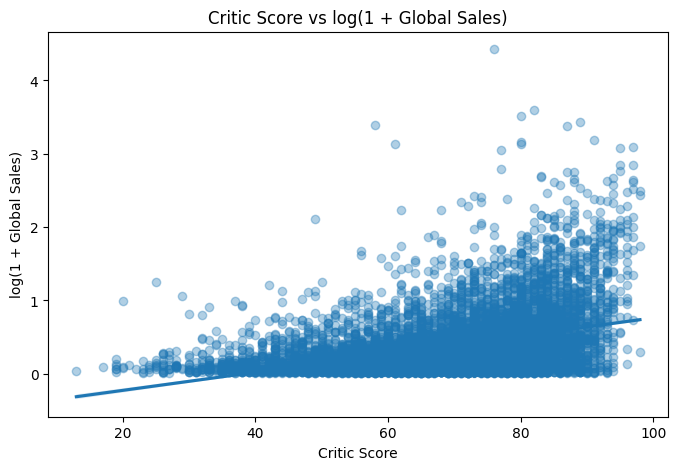

In [ ]:
plt.figure(figsize=(8,5))
sns.regplot(data=games, x="Critic_Score", y="Log_Global_Sales", scatter_kws={"alpha":0.35})
plt.title("Critic Score vs log(1 + Global Sales)")
plt.xlabel("Critic Score")
plt.ylabel("log(1 + Global Sales)")
plt.show()

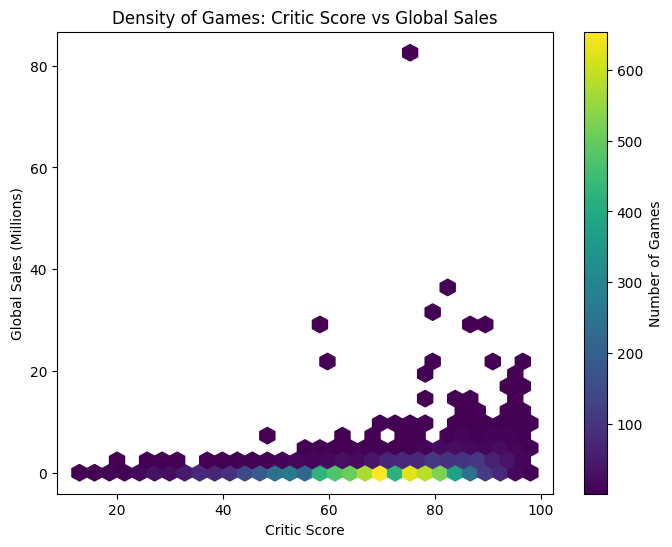

In [ ]:
plt.figure(figsize=(8,6))

plt.hexbin(
    games["Critic_Score"],
    games["Global_Sales"],
    gridsize=30,
    cmap="viridis",
    mincnt=1
)

plt.colorbar(label="Number of Games")

plt.xlabel("Critic Score")
plt.ylabel("Global Sales (Millions)")
plt.title("Density of Games: Critic Score vs Global Sales")

plt.show()

## Result: These plots show that there is a moderate correlation of higher critic scores being associated with slightly higher sales on average.

## Q2: Are user scores more predictive of commercial success than critic scores?


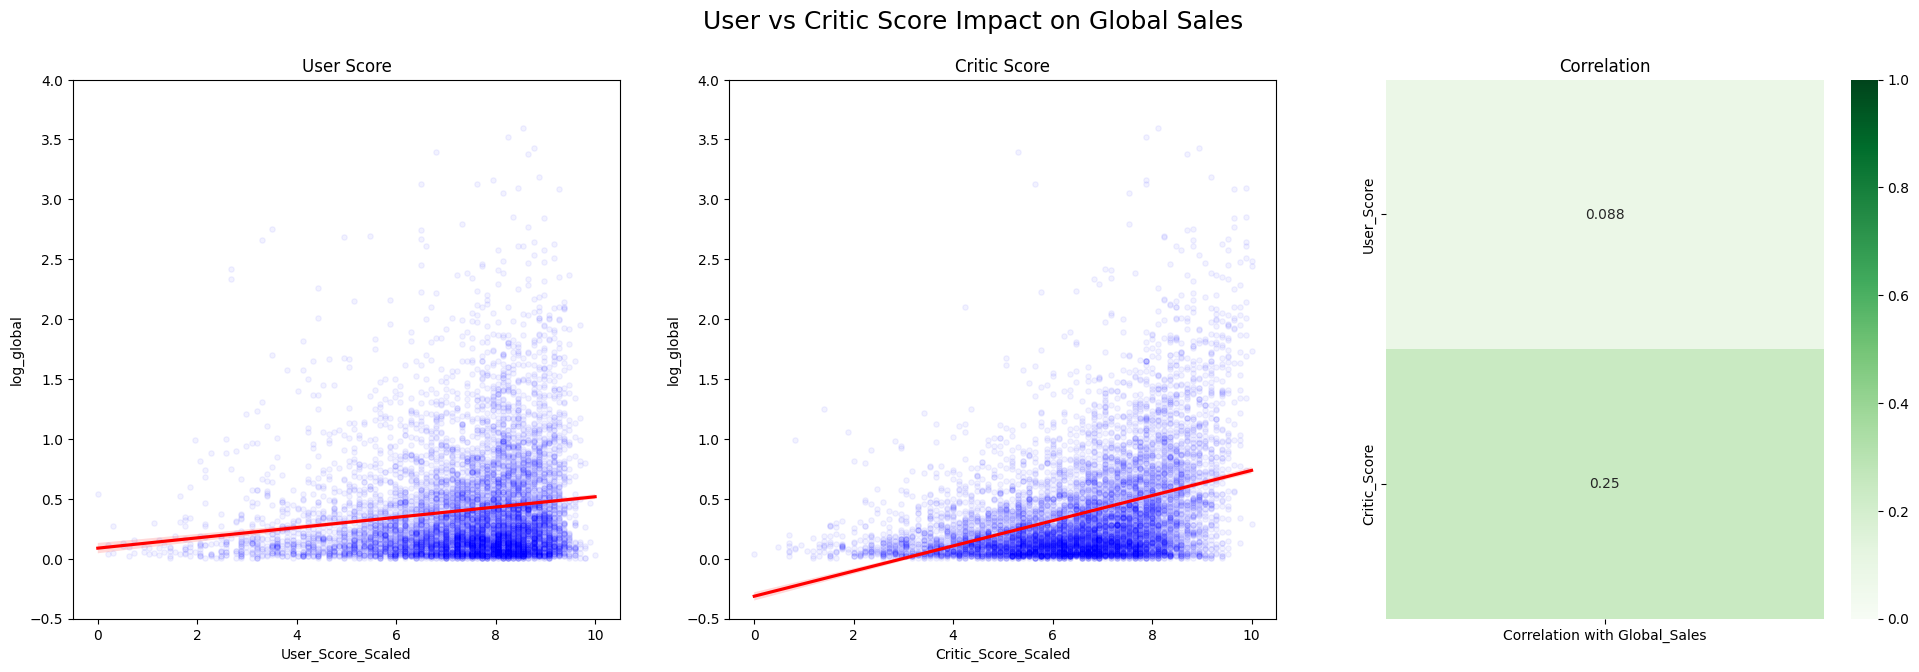

In [ ]:
games["log_global"] = np.log1p(games["Global_Sales"])

fig, axes = plt.subplots(1, 3, figsize=(24, 7))

fig.suptitle("User vs Critic Score Impact on Global Sales", fontsize=18)

sns.regplot(data=games, x='User_Score_Scaled', y="log_global", scatter_kws={'alpha':0.05, 's':15, 'color':"blue"}, color="red", ax=axes[0])
axes[0].set_ylim(-.5, 4)
axes[0].set_title("User Score")

sns.regplot(data=games, x='Critic_Score_Scaled', y="log_global", scatter_kws={'alpha':0.05, 's':15, 'color':"blue"}, color="red", ax=axes[1])
axes[1].set_title("Critic Score")
axes[1].set_ylim(-.5, 4)

corr_user_sale = games['User_Score_Scaled'].corr(games['Global_Sales'])
corr_critic_sale = games['Critic_Score_Scaled'].corr(games['Global_Sales'])

corr_df = pd.DataFrame({'Correlation with Global_Sales': [corr_user_sale, corr_critic_sale]}, index=["User_Score", "Critic_Score"])

sns.heatmap(corr_df, annot=True, cmap='Greens', vmin=0, vmax=1, ax=axes[2])
axes[2].set_title("Correlation")

plt.show()

## Result: The association between Critic_Score and Global_Sales is stronger than the association between User_Score and Global_Sales

## Q3: Does the relationship between ratings and sales vary by genre?


/tmp/ipykernel_4356/3852729981.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  genre_corr = games.groupby('Genre').apply(
/tmp/ipykernel_4356/3852729981.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  genre_corr = games.groupby('Genre').apply(


Text(0.5, 1.0, 'User_Score')

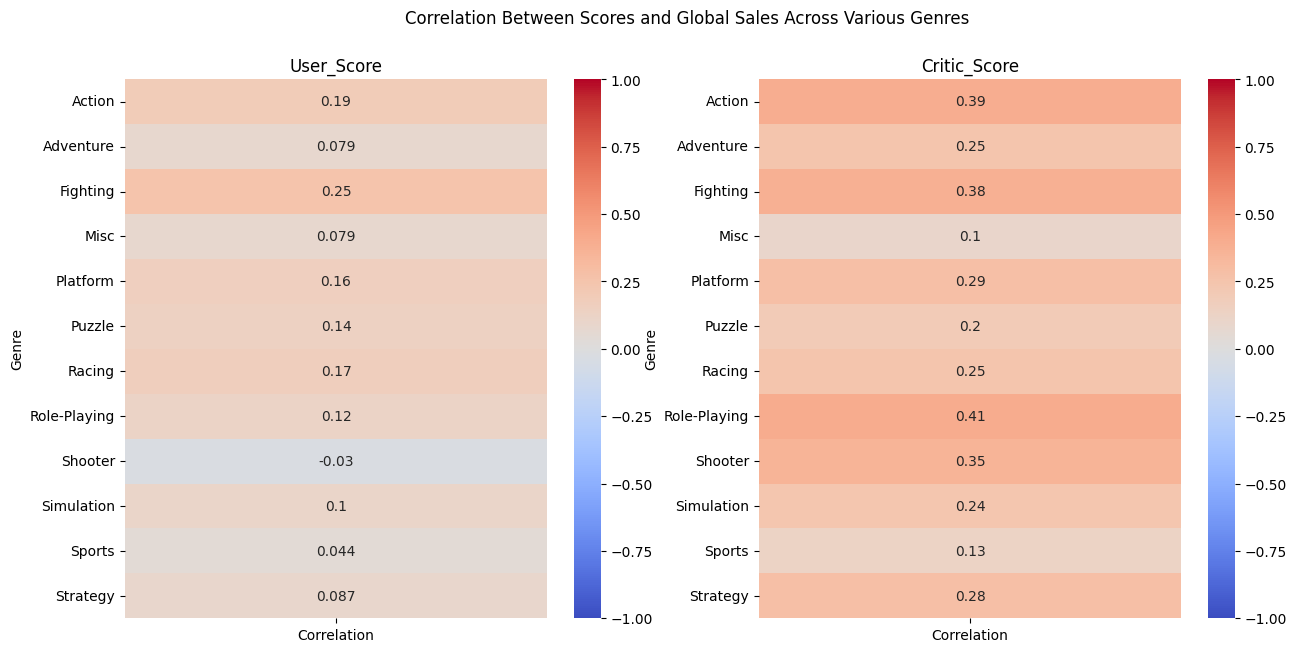

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7))
fig.suptitle("Correlation Between Scores and Global Sales Across Various Genres")

genre_corr = games.groupby('Genre').apply(
    lambda x: x['Global_Sales'].corr(x['Critic_Score'])
)

genre_corr = genre_corr.to_frame(name='Correlation')

sns.heatmap(genre_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title("Critic_Score")

genre_corr = games.groupby('Genre').apply(
    lambda x: x['Global_Sales'].corr(x['User_Score'])
)

genre_corr = genre_corr.to_frame(name='Correlation')

sns.heatmap(genre_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title("User_Score")

## Result: Yes, generally fighting and action games had higher correlation between scores and true global sales. For critics, the correlation between misc games and sports games were much lower. Similarly, for user scores shooters and sports game had less correlation, although user scores had less correlation with sales in general

## Q4: Has the predictive power of review scores changed over the years?



/tmp/ipykernel_4356/4041570315.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  games_analysis['Year_of_Release'] = games_analysis['Year_of_Release'].astype(int)
/tmp/ipykernel_4356/4041570315.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  games_analysis['Year_Group'] = pd.cut(games_analysis['Year_of_Release'], bins=5, include_lowest=True)
/tmp/ipykernel_4356/4041570315.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass ob

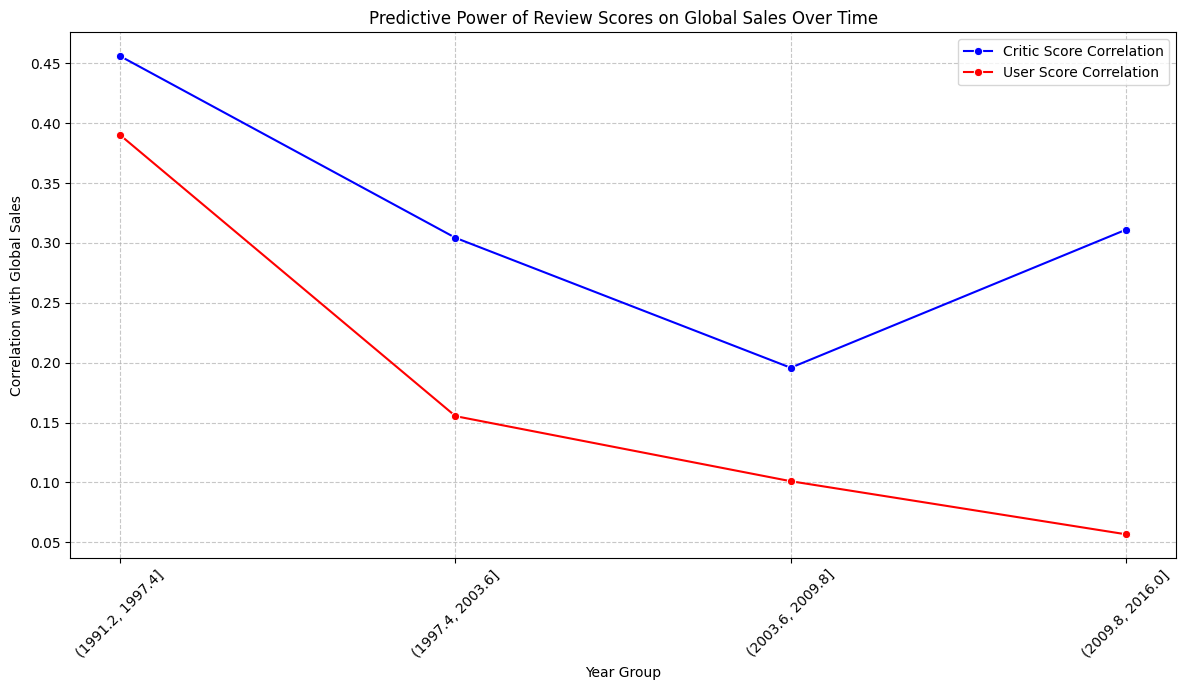

In [ ]:
games["Critic_Score_Scaled"] = games["Critic_Score"] / 10

games_analysis = games.dropna(subset=['Year_of_Release', 'Critic_Score_Scaled', 'User_Score_Scaled', 'Global_Sales'])
games_analysis['Year_of_Release'] = games_analysis['Year_of_Release'].astype(int)

games_analysis['Year_Group'] = pd.cut(games_analysis['Year_of_Release'], bins=5, include_lowest=True)

critic_corr_over_time = games_analysis.groupby('Year_Group').apply(lambda x: x['Critic_Score_Scaled'].corr(x['Global_Sales']) if len(x) > 1 and x['Critic_Score_Scaled'].std() != 0 and x['Global_Sales'].std() != 0 else np.nan)
user_corr_over_time = games_analysis.groupby('Year_Group').apply(lambda x: x['User_Score_Scaled'].corr(x['Global_Sales']) if len(x) > 1 and x['User_Score_Scaled'].std() != 0 and x['Global_Sales'].std() != 0 else np.nan)


# Combine into a DataFrame for plotting
corr_df_over_time = pd.DataFrame({
    'Critic_Score_Correlation': critic_corr_over_time,
    'User_Score_Correlation': user_corr_over_time
})

corr_df_over_time = corr_df_over_time.reset_index()

corr_df_over_time['Year_Group_Str'] = corr_df_over_time['Year_Group'].astype(str)


plt.figure(figsize=(12, 7))
sns.lineplot(data=corr_df_over_time, x='Year_Group_Str', y='Critic_Score_Correlation', label='Critic Score Correlation', marker='o', color='blue')
sns.lineplot(data=corr_df_over_time, x='Year_Group_Str', y='User_Score_Correlation', label='User Score Correlation', marker='o', color='red')

plt.title('Predictive Power of Review Scores on Global Sales Over Time')
plt.xlabel('Year Group')
plt.ylabel('Correlation with Global Sales')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

## Result: The predictive power of review scores were on a downward trend for the past few decades, however recently there has been a rise in the critic score correlation.

## Q5: How does the distribution of global video game sales differ across platforms?

In [ ]:
# Write your code here
platform_options = sorted(games["Platform"].dropna().unique().tolist())

platform_multi = pnw.MultiChoice(
    name="Platforms",
    value=[platform_options[0]],
    options=platform_options
)

year_slider = pnw.IntRangeSlider(
    name="Release Year Range",
    start=int(games["Year_of_Release"].min(skipna=True)),
    end=int(games["Year_of_Release"].max(skipna=True)),
    value=(
        int(games["Year_of_Release"].min(skipna=True)),
        int(games["Year_of_Release"].max(skipna=True)),
    )
)

def dashboard_plot(platforms, year_range):
    temp = games.copy()
    temp = temp[temp["Platform"].isin(platforms)]
    temp = temp[
        (temp["Year_of_Release"] >= year_range[0]) &
        (temp["Year_of_Release"] <= year_range[1])
    ]

    temp["Log_Sales"] = np.log1p(temp["Global_Sales"])

    plot = px.box(
        temp,
        x="Platform",
        y="Log_Sales",
        points="outliers",
        hover_name="Name",
        hover_data={
            "Genre": True,
            "Year_of_Release": True,
            "Global_Sales": ":.2f",
            "Platform": False
        },
        title="Distribution of Global Video Game Sales by Platform (Log Scale)",
        labels={"Log_Sales": "log(1 + Global Sales)", "Platform": "Platform"}
    )

    return plot

def dashboard_table(platforms, year_range):
  temp = games.copy()
  temp = temp[temp["Platform"].isin(platforms)]
  temp = temp[
      (temp["Year_of_Release"] >= year_range[0]) & (temp["Year_of_Release"] <= year_range[1])
  ]

  return temp[["Name", "Platform", "Genre", "Year_of_Release", "Global_Sales"]].head(15)

dashboardplot = pn.bind(dashboard_plot, platforms=platform_multi, year_range=year_slider)
dashboardtable = pn.bind(dashboard_table, platforms=platform_multi, year_range=year_slider)

dashboard = pn.Column(
    "## Mini Dashboard",
    pn.Row(platform_multi, year_slider),
    pn.Row(
        pn.pane.Plotly(dashboardplot, config={"responsive": True}),
        pn.widgets.Tabulator(
            dashboardtable,
            show_index=False,
            width=700,
            height=400,
            theme="default"
        )
    )
)

dashboard

Column
    [0] Markdown(str)
    [1] Row
        [0] MultiChoice(name='Platforms', options=['2600', '3DO', ...], value=['2600'])
        [1] IntRangeSlider(end=2020, name='Release Year Range', start=1980, value=(1980, 2020), value_end=2020, value_start=1980)
    [2] Row
        [0] Plotly(Figure, config={'responsive': True})
        [1] Tabulator(height=400, show_index=False, sizing_mode='fixed', theme='default', value=              ..., width=700)

## Result: Home Consoles like the Xbox360, PS3, and PS2, tend to have higher median and variable global sales than handheld consoles and PCs, which show lower average sales and less high selling titles.

## Main Takeaway: Some of our predictions turned out to be incorrect, such as critic scores turning out to have a stronger correlation with sales than user scores, and the predictive power of reviews weakening over time. However some of our predictions were also very accurate, such as specfific platforms having greater sales and varability due to other factors, and some genres having a stronger relationship depending on their popularity.